In [1]:
library(ggplot2)
library(data.table)
theme_set(theme_bw())

# Source - https://stackoverflow.com/a
# Posted by dfrankow
# Retrieved 2026-01-16, License - CC BY-SA 3.0

options(repr.matrix.max.rows=600, repr.matrix.max.cols=200)

options(repr.plot.width = 10)

In [2]:
novelties = c(0.5, 0.95, 1.25)
communities = paste0('marine', seq(0, length(novelties) - 1), "novelty", novelties)
d1a = data.table(expand.grid(community = communities,
                            ts = c(0.01, 0.02, 0.03, 0.04, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5),
                            mask = seq(0, 4)))
d1a[, `:=`(tg = ts, tf = ts, to = ts, tc = ts, tp = ts, td = ts, tr = ts, set = "a")]
d1b = data.table(expand.grid(community = communities,
                             ts = c(0.1, 0.2, 0.25, 0.3, 0.35, 0.4), tf = 0.3, to = 0.3, tc = 0.3,
                             tp = 0.3, td = 0.3, tr = 0.3,
                             mask = seq(0, 4), set = "b"))
d1b[, tg := round(1.1 - ts, 5) ]
d1 = merge(d1a, d1b,
           by = c("community", "ts", "tg", "tf", "to", "tc", "tp", "td", "tr", "mask"),
           all = TRUE)
dim(d1)
d1[set.x == "a" & set.y == "b",]

[1] 240  12

community,ts,tg,tf,to,tc,tp,td,tr,mask,set.x,set.y
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<fct>


In [3]:
# output_singlem/opal/GCA_022615805.1_genomic.opal_report
readit = function(community, ts, tg, tf, to, tc, tp, td, tr, mask){
    to_read = paste0('output_singlem_dev/opal/tune_s', ts, 'g', tg, 'f', tf, 'o', to, 'c', tc,
                     'p', tp, 'd', td, 'r', tr, 'mask', mask, '/', community,'.opal_report')
    #if (!file.exists(to_read)) return()
    return(fread(to_read))
}
d2 = d1[, readit(community, ts, tg, tf, to, tc, tp, td, tr, mask),
        by=list(community, ts, tg, tf, to, tc, tp, td, tr, mask, set.x, set.y)]

In [4]:
#d2 = data.table(community = communities[1], ts = 0.1, tg = 0,
#                tf = 0, to = 0, tc = 0, tp = 0, td = 0, tr = 0,
#                mask = 0)[, readit(community, ts, tg, tf, to, tc, tp, td, tr, mask),
#                          by = list(community, ts, tg, tf, to, tc, tp, td, tr, mask)]
dim(d2)
d2[1:5,]

[1] 43148    17

community,ts,tg,tf,to,tc,tp,td,tr,mask,set.x,set.y,tool,rank,metric,sample,value
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<fct>,<chr>,<chr>,<chr>,<chr>,<dbl>
marine0novelty0.5,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0,a,NA,Gold standard,kingdom,Bray-Curtis distance,SAMPLEID,0
marine0novelty0.5,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0,a,NA,Gold standard,phylum,Bray-Curtis distance,SAMPLEID,0
marine0novelty0.5,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0,a,NA,Gold standard,class,Bray-Curtis distance,SAMPLEID,0
marine0novelty0.5,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0,a,NA,Gold standard,order,Bray-Curtis distance,SAMPLEID,0
marine0novelty0.5,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0,a,NA,Gold standard,family,Bray-Curtis distance,SAMPLEID,0


In [5]:
s1 = d2[tool != "Gold standard" & metric == "Bray-Curtis distance"]
s1[, rank := factor(rank, c('kingdom','phylum','class','order','family','genus','species'))]
setnames(s1, "value", "Bray-Curtis distance")

In [6]:
# Remove figure legend title, and put the legend in bottom left of plot, with a bounding box
plot_bc <- function(data) {
   ggplot(data, aes(rank, `Bray-Curtis distance`)) +
      geom_boxplot() +
      scale_x_discrete(na.translate = FALSE) +
      theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
      theme(legend.title=element_blank()) +
      theme(legend.position=c(0.1,0.4)) +
      theme(legend.background = element_rect(colour = "black", linewidth = 0.3))
}

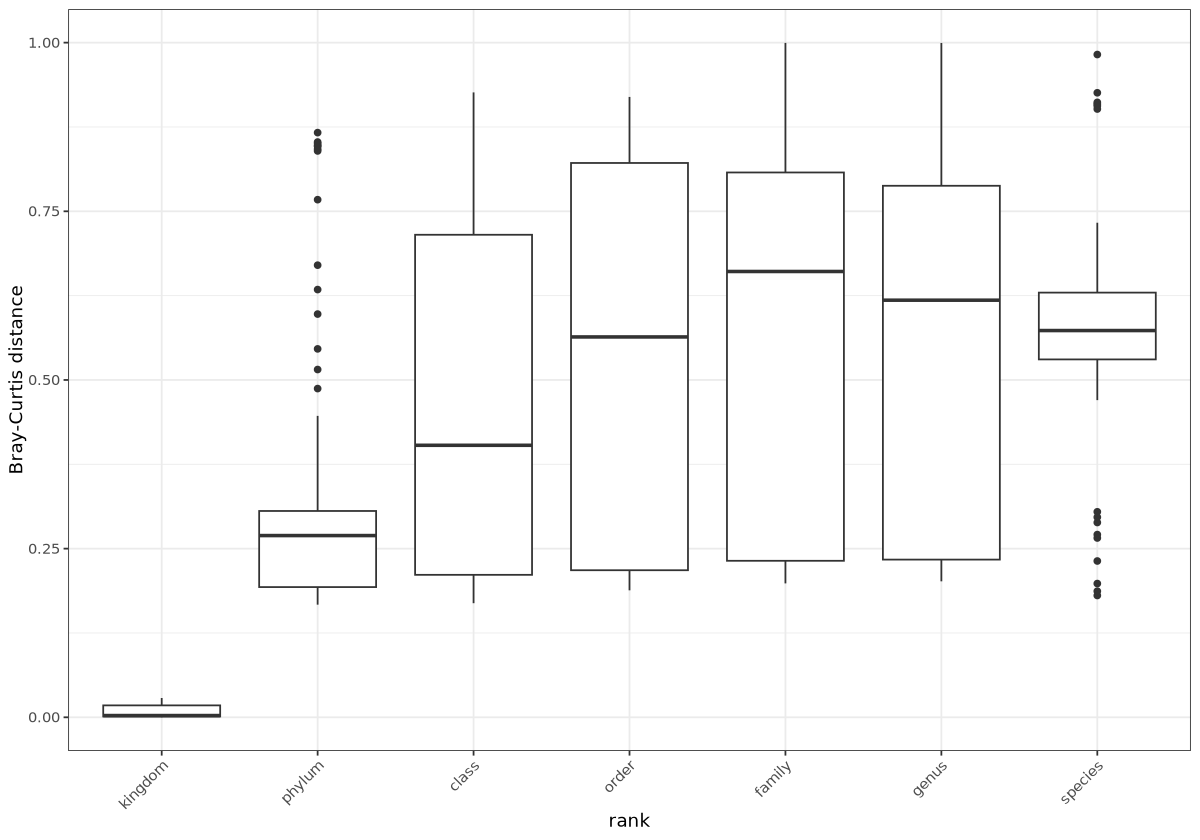

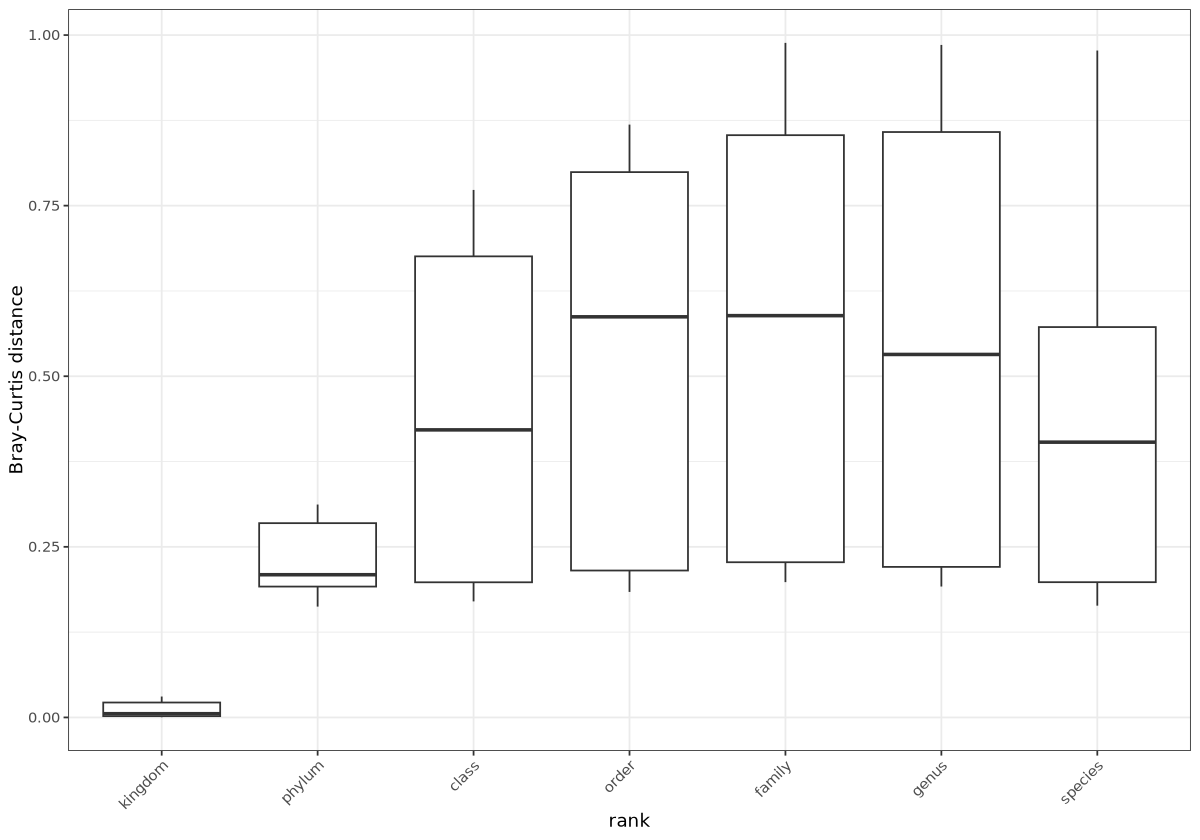

In [7]:
plot_bc(s1[set.x == "a"])
plot_bc(s1[set.y == "b"])

# NMF penalty tuning

In [8]:
readloss = function(community, ts, tg, tf, to, tc, tp, td, tr, mask){
    to_read = paste0('output_singlem_dev/singlem_dev/tune_s', ts, 'g', tg, 'f', tf, 'o', to, 'c', tc,
                     'p', tp, 'd', td, 'r', tr, 'mask', mask, '/', community,'.loss.tsv')
    #if (!file.exists(to_read)) return()
    return(fread(to_read, header = FALSE, col.names = c("metric", "value")))
}
d3 = d1[, readloss(community, ts, tg, tf, to, tc, tp, td, tr, mask),
        by=list(community, ts, tg, tf, to, tc, tp, td, tr, mask, set.x, set.y)]

In [9]:
#d2 = data.table(community = communities[1], ts = 0.1, tg = 0,
#                tf = 0, to = 0, tc = 0, tp = 0, td = 0, tr = 0,
#                mask = 0)[, readloss(community, ts, tg, tf, to, tc, tp, td, tr, mask),
#                          by = list(community, ts, tg, tf, to, tc, tp, td, tr, mask)]
d3[1:5,]

community,ts,tg,tf,to,tc,tp,td,tr,mask,set.x,set.y,metric,value
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<fct>,<chr>,<dbl>
marine0novelty0.5,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0,a,NA,NMF loss,41.386
marine0novelty0.5,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0,a,NA,NMF mask loss,113.952
marine0novelty0.5,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0,a,NA,NMF penalised loss,49.203
marine0novelty0.5,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0,a,NA,NMF steps,4826.000
marine0novelty0.5,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,1,a,NA,NMF loss,45.527


In [10]:
s1_sg = s1[rank %in% c("species", "genus")]
s1_sg[, c("metric", "tool", "rank", "sample") := list(paste0("Bray-Curtis distance ", rank), NULL, NULL, NULL)]
d4 = rbind(
    d3,
    setnames(s1_sg, "Bray-Curtis distance", "value")
)
d4[1:5]

community,ts,tg,tf,to,tc,tp,td,tr,mask,set.x,set.y,metric,value
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<fct>,<chr>,<dbl>
marine0novelty0.5,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0,a,NA,NMF loss,41.386
marine0novelty0.5,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0,a,NA,NMF mask loss,113.952
marine0novelty0.5,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0,a,NA,NMF penalised loss,49.203
marine0novelty0.5,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0,a,NA,NMF steps,4826.000
marine0novelty0.5,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,1,a,NA,NMF loss,45.527


In [11]:
d4_steps = d4[metric == "NMF steps"]
d4_steps[, metric := NULL]
setnames(d4_steps, "value", "steps")
d5 = d4[!metric %in% c("NMF steps", "NMF penalised loss"), ][d4_steps, on = .NATURAL]
d5[1:5]

community,ts,tg,tf,to,tc,tp,td,tr,mask,set.x,set.y,metric,value,steps
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<fct>,<chr>,<dbl>,<dbl>
marine0novelty0.5,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0,a,NA,NMF loss,41.3860000,4826
marine0novelty0.5,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0,a,NA,NMF mask loss,113.9520000,4826
marine0novelty0.5,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0,a,NA,Bray-Curtis distance genus,0.3106742,4826
marine0novelty0.5,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0,a,NA,Bray-Curtis distance species,0.7330846,4826
marine0novelty0.5,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,1,a,NA,NMF loss,45.5270000,5001


In [21]:
d5[set.y == "b" & ts == 0.3][1:5]

community,ts,tg,tf,to,tc,tp,td,tr,mask,set.x,set.y,metric,value,steps
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<fct>,<chr>,<dbl>,<dbl>
marine0novelty0.5,0.3,0.8,0.3,0.3,0.3,0.3,0.3,0.3,0,NA,b,NMF loss,77.4800000,590
marine0novelty0.5,0.3,0.8,0.3,0.3,0.3,0.3,0.3,0.3,0,NA,b,NMF mask loss,116.7500000,590
marine0novelty0.5,0.3,0.8,0.3,0.3,0.3,0.3,0.3,0.3,0,NA,b,Bray-Curtis distance genus,0.2148336,590
marine0novelty0.5,0.3,0.8,0.3,0.3,0.3,0.3,0.3,0.3,0,NA,b,Bray-Curtis distance species,0.1864726,590
marine0novelty0.5,0.3,0.8,0.3,0.3,0.3,0.3,0.3,0.3,1,NA,b,NMF loss,90.2530000,478


In [ ]:
s2 = d5[,
        list(value = sum(value), steps = max(steps)),
        by = list(community, ts, tg, tf, to, tc, tp, td, tr, metric, set.x, set.y)]
s2[metric == "NMF loss", value := value / 4]
tunecols = c("ts", "tg", "tf", "to", "tc", "tp", "td", "tr")
s2atunecols <- s2[set.x == "a", lapply(.SD, \(x) factor(x, levels = unique(sort(x)))), .SDcols = tunecols]
for (i in seq(2, length(tunecols))) {
    s2[[tunecols[i]]] = round(s2[[tunecols[i]]] + s2[[tunecols[i-1]]], 5)
}
s2btunecols <- s2[set.y == "b", lapply(.SD, \(x) factor(x, levels = unique(sort(x)))), .SDcols = tunecols]
for (col in tunecols[1:2]) {
    s2[set.x == "a", paste0("g_", col)] <- interaction(s2atunecols[,setdiff(tunecols, col), with = FALSE])
    s2[set.y == "b", paste0("g_", col)] <- interaction(s2btunecols[,setdiff(tunecols, col), with = FALSE])
}
s2[1:10]

community,ts,tg,tf,to,tc,tp,td,tr,metric,set.x,set.y,value,steps,g_ts,g_tg
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<fct>,<dbl>,<dbl>,<fct>,<fct>
marine0novelty0.5,0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,NMF loss,a,NA,53.149000,5001,0.01.0.01.0.01.0.01.0.01.0.01.0.01,0.01.0.01.0.01.0.01.0.01.0.01.0.01
marine0novelty0.5,0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,NMF mask loss,a,NA,543.683000,5001,0.01.0.01.0.01.0.01.0.01.0.01.0.01,0.01.0.01.0.01.0.01.0.01.0.01.0.01
marine0novelty0.5,0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,Bray-Curtis distance genus,a,NA,1.573315,5001,0.01.0.01.0.01.0.01.0.01.0.01.0.01,0.01.0.01.0.01.0.01.0.01.0.01.0.01
marine0novelty0.5,0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,Bray-Curtis distance species,a,NA,3.300677,5001,0.01.0.01.0.01.0.01.0.01.0.01.0.01,0.01.0.01.0.01.0.01.0.01.0.01.0.01
marine0novelty0.5,0.02,0.04,0.06,0.08,0.10,0.12,0.14,0.16,NMF loss,a,NA,57.435500,4131,0.02.0.02.0.02.0.02.0.02.0.02.0.02,0.02.0.02.0.02.0.02.0.02.0.02.0.02
marine0novelty0.5,0.02,0.04,0.06,0.08,0.10,0.12,0.14,0.16,NMF mask loss,a,NA,541.520000,4131,0.02.0.02.0.02.0.02.0.02.0.02.0.02,0.02.0.02.0.02.0.02.0.02.0.02.0.02
marine0novelty0.5,0.02,0.04,0.06,0.08,0.10,0.12,0.14,0.16,Bray-Curtis distance genus,a,NA,1.311873,4131,0.02.0.02.0.02.0.02.0.02.0.02.0.02,0.02.0.02.0.02.0.02.0.02.0.02.0.02
marine0novelty0.5,0.02,0.04,0.06,0.08,0.10,0.12,0.14,0.16,Bray-Curtis distance species,a,NA,3.124456,4131,0.02.0.02.0.02.0.02.0.02.0.02.0.02,0.02.0.02.0.02.0.02.0.02.0.02.0.02
marine0novelty0.5,0.03,0.06,0.09,0.12,0.15,0.18,0.21,0.24,NMF loss,a,NA,60.362750,2965,0.03.0.03.0.03.0.03.0.03.0.03.0.03,0.03.0.03.0.03.0.03.0.03.0.03.0.03


In [19]:
s2[set.y == "b"][1:10]

community,ts,tg,tf,to,tc,tp,td,tr,metric,set.x,set.y,value,steps,g_ts,g_tg
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<fct>,<dbl>,<dbl>,<fct>,<fct>
marine0novelty0.5,0.10,1.1,1.4,1.7,2,2.3,2.6,2.9,NMF loss,NA,b,108.6375000,1148,1.1.1.4.1.7.2.2.3.2.6.2.9,0.1.1.4.1.7.2.2.3.2.6.2.9
marine0novelty0.5,0.10,1.1,1.4,1.7,2,2.3,2.6,2.9,NMF mask loss,NA,b,537.9940000,1148,1.1.1.4.1.7.2.2.3.2.6.2.9,0.1.1.4.1.7.2.2.3.2.6.2.9
marine0novelty0.5,0.10,1.1,1.4,1.7,2,2.3,2.6,2.9,Bray-Curtis distance genus,NA,b,0.9998653,1148,1.1.1.4.1.7.2.2.3.2.6.2.9,0.1.1.4.1.7.2.2.3.2.6.2.9
marine0novelty0.5,0.10,1.1,1.4,1.7,2,2.3,2.6,2.9,Bray-Curtis distance species,NA,b,0.8588476,1148,1.1.1.4.1.7.2.2.3.2.6.2.9,0.1.1.4.1.7.2.2.3.2.6.2.9
marine0novelty0.5,0.20,1.1,1.4,1.7,2,2.3,2.6,2.9,NMF loss,NA,b,107.8657500,697,1.1.1.4.1.7.2.2.3.2.6.2.9,0.2.1.4.1.7.2.2.3.2.6.2.9
marine0novelty0.5,0.20,1.1,1.4,1.7,2,2.3,2.6,2.9,NMF mask loss,NA,b,536.3860000,697,1.1.1.4.1.7.2.2.3.2.6.2.9,0.2.1.4.1.7.2.2.3.2.6.2.9
marine0novelty0.5,0.20,1.1,1.4,1.7,2,2.3,2.6,2.9,Bray-Curtis distance genus,NA,b,1.0624854,697,1.1.1.4.1.7.2.2.3.2.6.2.9,0.2.1.4.1.7.2.2.3.2.6.2.9
marine0novelty0.5,0.20,1.1,1.4,1.7,2,2.3,2.6,2.9,Bray-Curtis distance species,NA,b,0.9628643,697,1.1.1.4.1.7.2.2.3.2.6.2.9,0.2.1.4.1.7.2.2.3.2.6.2.9
marine0novelty0.5,0.25,1.1,1.4,1.7,2,2.3,2.6,2.9,NMF loss,NA,b,107.9210000,823,1.1.1.4.1.7.2.2.3.2.6.2.9,0.25.1.4.1.7.2.2.3.2.6.2.9


In [15]:
scale <- function(data) {
    data[, `:=`(min = min(value), max = max(value)), by = list(community, metric)]
    data[, value := (value - min) / (max - min)]
}
plot_slope <- function(data) {
    ggplot(data, aes(1/ts, value, colour = metric,
                     alpha = steps < 5000, group = metric)) +
    geom_point() +
    geom_line() +
    #scale_x_continuous(transform = scales::transform_reciprocal()) +
    facet_wrap(vars(community), scales = "free_y") +
    theme(legend.title=element_blank()) +
    theme(legend.position="bottom") +
    theme(legend.background = element_rect(colour = "black", linewidth = 0.3))
}

Warning message:
“Using alpha for a discrete variable is not advised.”


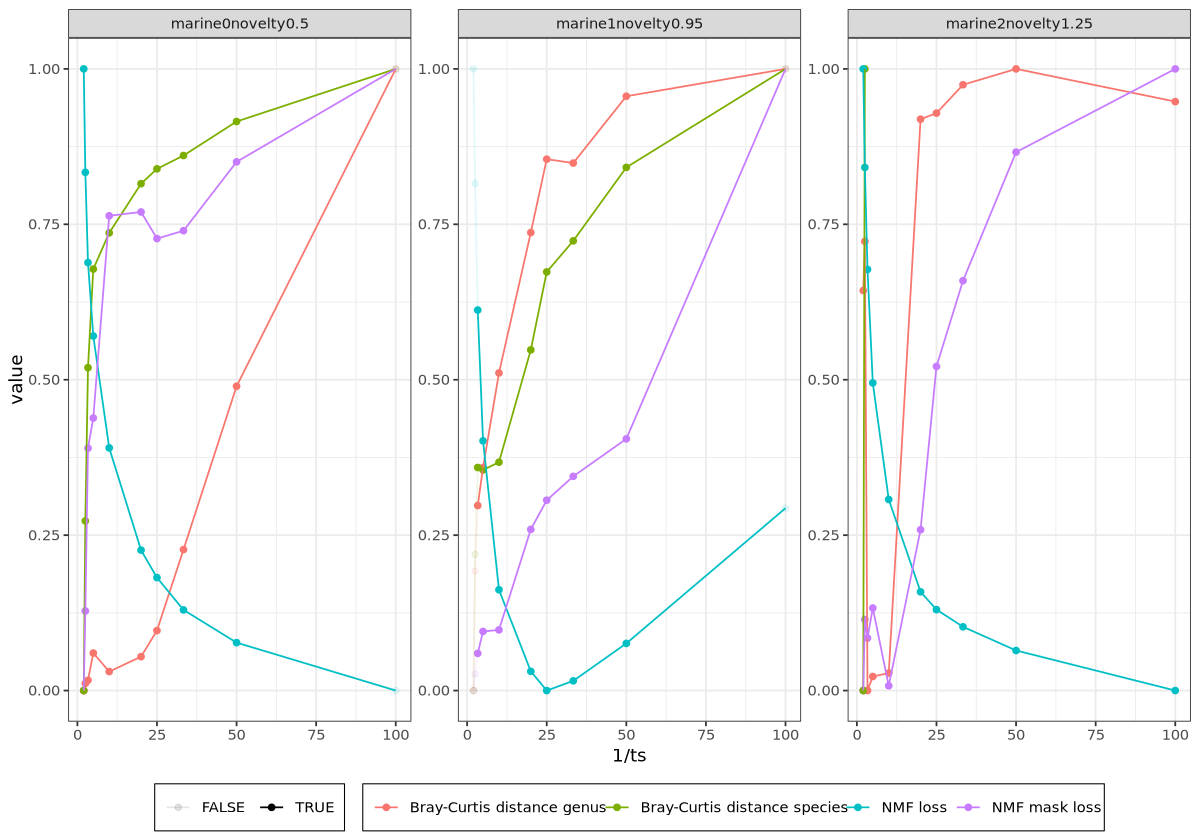

In [16]:
plot_slope(scale(s2[set.x == "a"]))

In [17]:
plot_rank <- function(data, rank) {
    #data[["group"]] <- interaction(data[, c(paste0("g_", rank), "metric"), with = FALSE])
    data[["col"]] <- data[[paste0("g_", rank)]]
    ggplot(data, aes(1/.data[[rank]], value, colour = metric,
                     alpha = steps < 5000,
                     group = metric)) +
    geom_point() +
    geom_line() +
    facet_grid(vars(community), vars(col)) +
    theme(legend.title=element_blank()) +
    theme(legend.position="bottom") +
    #theme(legend.position=c(0.1,0.4)) +
    theme(legend.background = element_rect(colour = "black", linewidth = 0.3)) +
    theme(strip.text.x = element_text(size = 8))
}

Warning message:
“Using alpha for a discrete variable is not advised.”


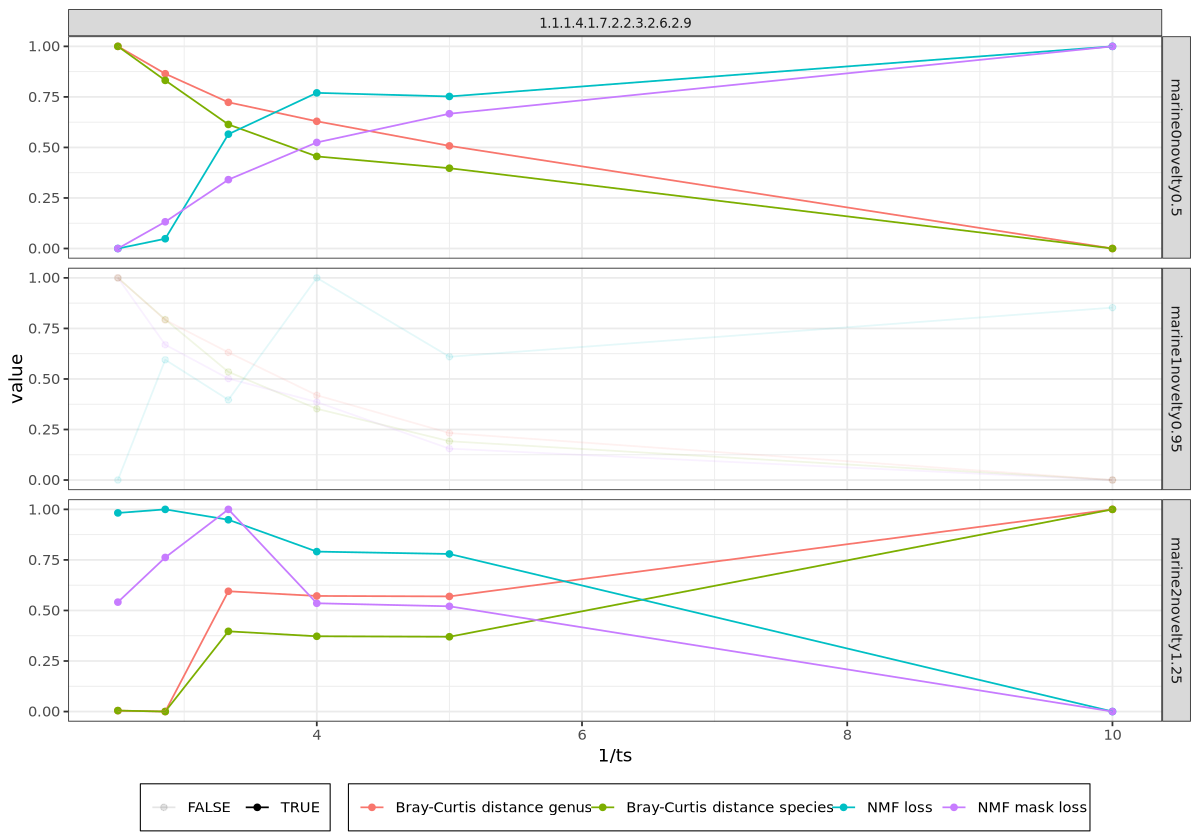

In [18]:
plot_rank(scale(s2[set.y == "b"]), "ts")

In [22]:
1/0.3

[1] 3.333333

In [ ]:
plot_rank(s2[set.y == "b"], "tg")